In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dragonheir/logistic-regression")

print("Path to dataset files:", path)

/home/rohnak.agarwal/projects/ml-practice/venv312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 3.27k/3.27k [00:00<00:00, 4.74MB/s]

Extracting files...
Path to dataset files: /home/rohnak.agarwal/.cache/kagglehub/datasets/dragonheir/logistic-regression/versions/1


In [2]:
import os

os.listdir(path)

['Social_Network_Ads.csv']

In [3]:
import os, pandas as pd

df = pd.read_csv(os.path.join(path, "Social_Network_Ads.csv"))
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [5]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


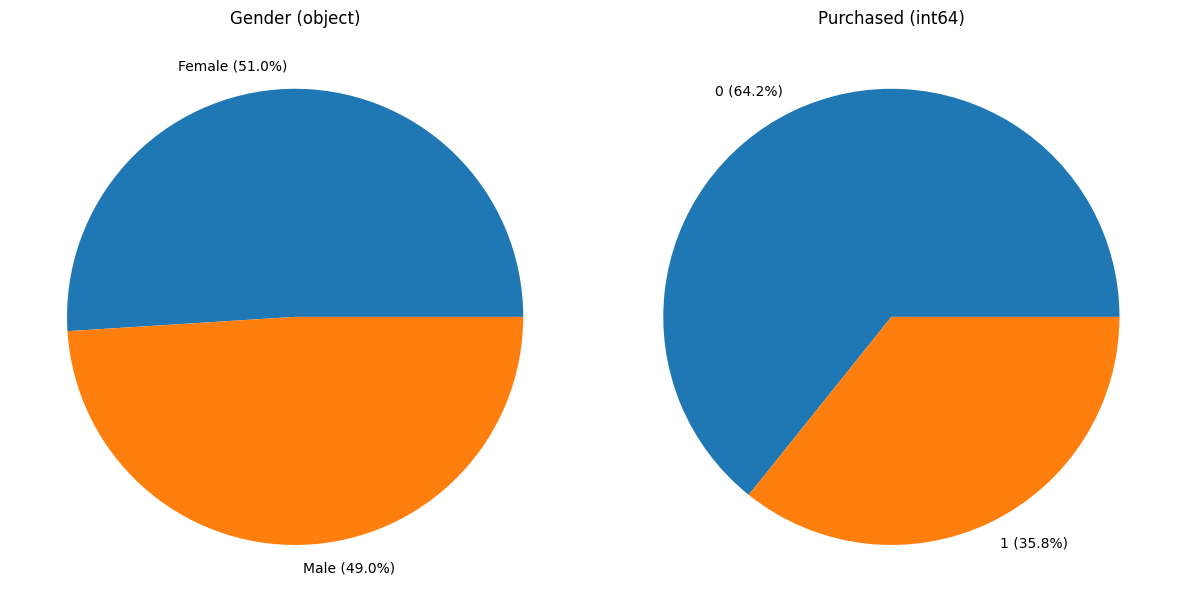

In [7]:
import matplotlib.pyplot as plt

cols = [col for col in df.select_dtypes(["object", int])]
num_plots = len(cols)
cols_per_row = 4
rows = (num_plots + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(6 * cols_per_row, 6 * rows))
axes = axes.flatten()

plot_idx = 0
for col in cols:
    unq_vals = df[col].unique()
    if len(unq_vals) > 10:
        continue

    freq_map = {}
    for val in sorted(unq_vals):
        count = len(df[df[col] == val])
        freq_map[f"{val} ({count * 100 / len(df):.1f}%)"] = count

    ax = axes[plot_idx]
    ax.pie(list(freq_map.values()), labels=list(freq_map.keys()))
    ax.set_title(f"{col} ({df[col].dtype})")
    plot_idx += 1

# Hide any unused axes
for i in range(plot_idx, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()